<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-4/blob/main/%5BMALU%5D_Squad_Dorothy_Vaughan_Challenge_Teste_de_Hip%C3%B3tese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cenário:

Imagine que você trabalha em uma empresa que fabrica suplementos
alimentares. O time de produtos quer entender qual das três novas
fórmulas de proteína em pó proporciona maior ganho de massa muscular
em atletas.
Foi realizada uma pesquisa com vários atletas e coletados os seguintes
dados, organizados em um csv.

## Variáveis:
* id_produto: Código identificador do suplemento (Fórmula 1, 2 ou 3).
* id_atleta: Código identificador do atleta que participou do estudo.
* ganho_massa: Quantidade de massa muscular ganha (em kg) após 8
semanas de uso.
* idade: Idade do atleta.
* frequencia_treino: Número médio de treinos semanais do atleta.


## Questões a serem respondidas:
1. Faça uma análise exploratória dos dados:
* Qual é a média e a mediana do ganho de massa para cada
suplemento?
* Como os dados estão distribuídos? Utilize histogramas e
boxplots para visualizar as diferenças entre as fórmulas.
* Há outliers no ganho de massa muscular? O que isso pode
indicar?  

2. Há diferença estatisticamente significativa no ganho de massa
muscular entre as três fórmulas?
3. Existe correlação entre idade e ganho de massa muscular? Atletas
mais jovens ou mais velhos têm resultados diferentes?
4. Atletas que treinam mais frequentemente ganham mais massa
muscular independentemente do suplemento?
5. Existe alguma correlação entre idade, frequência de treino e a
eficácia do suplemento?
6. Qual fórmula você recomendaria para atletas que treinam mais de 5
vezes por semana? Justifique sua escolha.

# Preparando o ambiente

In [ ]:
# bibliotecas de base
import pandas as pd
import numpy as np

# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# bibliotecas auxiliares
from collections import Counter

# biblioteca para estatística
import scipy.stats as stats

# imports de apoio
from scipy.stats import norm

In [ ]:
# Import do Dataset

url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/Challenge-Teste-de-Hipotese/refs/heads/main/desafio_03_suplementos.csv'
df_atletas = pd.read_csv(url)

In [ ]:
df_atletas.head(4)

,id_produto,id_atleta,ganho_massa,idade,frequencia_treino
0,Fórmula 3,1,2.24,27,5
1,Fórmula 1,2,4.97,35,4
2,Fórmula 3,3,0.88,30,6
3,Fórmula 3,4,0.09,22,6


In [ ]:
print('informações básicas do dataframe:')

print('-'*90)
print('\n\ntipos de dados de cada coluna:')
df_atletas.info()

print('-'*90)
print('\n\nverificando valores vazios nas colunas')
print(df_atletas.isnull().sum())

print('-'*90)
print('\n\nlinhas e colunas do dataframe')
print(df_atletas.shape)

print('-'*90)
print('\n\nestatísticas do dataframe')
df_atletas.drop(columns=['id_atleta']).describe()

informações básicas do dataframe:
------------------------------------------------------------------------------------------


tipos de dados de cada coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_produto         300 non-null    object 
 1   id_atleta          300 non-null    int64  
 2   ganho_massa        300 non-null    float64
 3   idade              300 non-null    int64  
 4   frequencia_treino  300 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 11.8+ KB
------------------------------------------------------------------------------------------


verificando valores vazios nas colunas
id_produto           0
id_atleta            0
ganho_massa          0
idade                0
frequencia_treino    0
dtype: int64
-------------------------------------------------------------------------------

,ganho_massa,idade,frequencia_treino
count,300.000000,300.000000,300.000000
mean,2.466733,28.123333,3.993333
std,1.436384,6.493742,1.430657
min,0.030000,18.000000,2.000000
25%,1.267500,22.000000,3.000000
50%,2.400000,28.000000,4.000000
75%,3.612500,34.000000,5.000000
max,4.980000,39.000000,6.000000


In [ ]:
df_atletas['id_produto'].value_counts()

,count
id_produto,
Fórmula 3,107
Fórmula 1,99
Fórmula 2,94


# Questão 01:

Faça uma análise exploratória dos dados:
* Qual é a média e a mediana do ganho de massa para cada suplemento?
* Como os dados estão distribuídos? Utilize histogramas e boxplots para visualizar as diferenças entre as fórmulas.
* Há outliers no ganho de massa muscular? O que isso pode indicar?

### Média e mediana no ganho de massa dos atletas por fórmula:

In [ ]:
df_medias = df_atletas.groupby('id_produto')['ganho_massa'].agg(
    media='mean',
    mediana='median',
    desvio='std',
    minimo='min',
    maximo='max'
).round(2)

df_medias

,media,mediana,desvio,minimo,maximo
id_produto,,,,,
Fórmula 1,2.66,2.67,1.39,0.09,4.98
Fórmula 2,2.35,2.15,1.40,0.03,4.98
Fórmula 3,2.39,2.35,1.51,0.08,4.97


### Distribuição dos dados por agrupamento de fórmulas

In [ ]:
from scipy.stats import shapiro

for formula in df_atletas['id_produto'].unique():

    dados = df_atletas[df_atletas['id_produto']==formula]['ganho_massa']

    stat,p = shapiro(dados)

    print(formula)
    print(f'Estatística={stat:.4f}')
    print(f'p-value={p:.4f}')

    if p>0.05:
        print("Distribuição normal")
    else:
        print("Distribuição não normal")

    print()

Fórmula 3
Estatística=0.9424
p-value=0.0002
Distribuição não normal

Fórmula 1
Estatística=0.9590
p-value=0.0036
Distribuição não normal

Fórmula 2
Estatística=0.9524
p-value=0.0018
Distribuição não normal



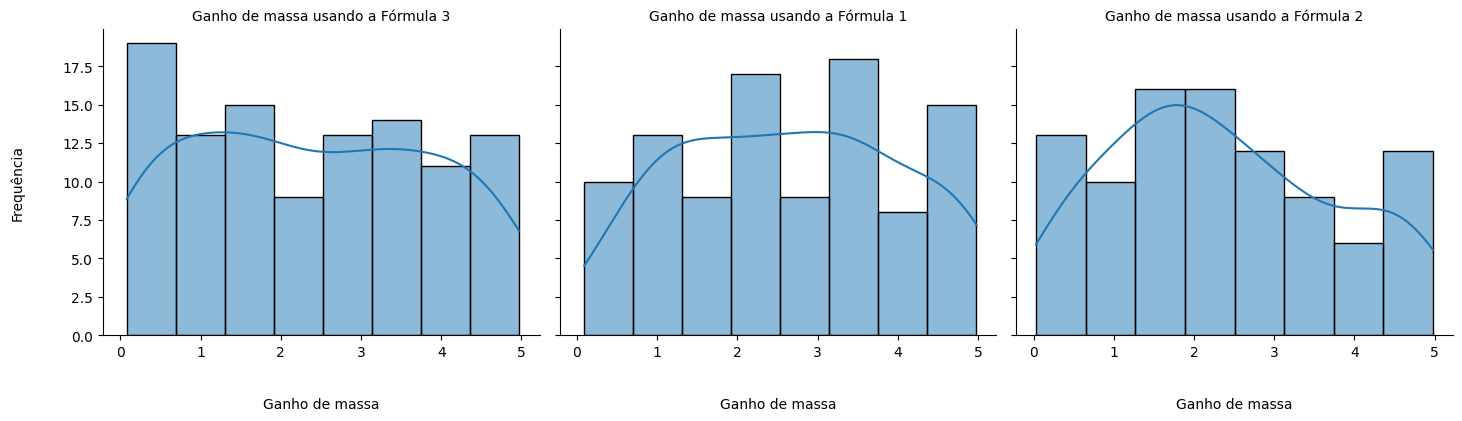

In [ ]:
g = sns.FacetGrid(
  df_atletas,
  col='id_produto',
  height=4,
  aspect=1.2
)

g.map(
  sns.histplot,
  'ganho_massa',
  bins=8,
  kde=True
)

g.set_axis_labels('\n\nGanho de massa', 'Frequência\n\n')
g.set_titles('Ganho de massa usando a {col_name}')

plt.show()

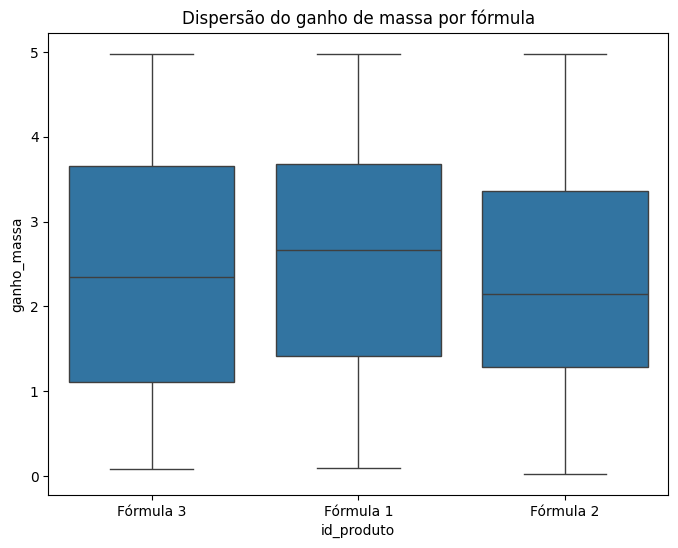

In [ ]:
# boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='id_produto', y='ganho_massa', data=df_atletas)
plt.title('Dispersão do ganho de massa por fórmula')
plt.show()

### Encontrando outliers e intepretando os gráficos

In [ ]:
outliers_encontrados = []

# fórmula para calcular os limites do boxplot
for formula in df_atletas['id_produto'].unique():
    dados_grupo = df_atletas[df_atletas['id_produto'] == formula]['ganho_massa']

    # calcular os quartis (Q1 e Q3)
    q1 = dados_grupo.quantile(0.25)
    q3 = dados_grupo.quantile(0.75)
    iqr = q3 - q1

    # definir os limites do boxplot
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # filtrar quem está fora dos limites
    outliers = dados_grupo[(dados_grupo < limite_inferior) | (dados_grupo > limite_superior)]

    for valor in outliers:
        outliers_encontrados.append({
            'Suplemento': formula,
            'Valor do Outlier (kg)': round(valor, 2),
            'Tipo': 'Inferior' if valor < limite_inferior else 'Superior'
        })

tabela_outliers = pd.DataFrame(outliers_encontrados)
print(tabela_outliers)

Empty DataFrame
Columns: []
Index: []


Ao analisarmos se possuimos outliers com a verificação utilizando a regra do Intervalo Interquartil ($1.5 \times IQR$), constatou-se que não há outliers no conjunto de dados.

O que isso indica: Isso indica que os dados coletados são consistentes. Não houve erros graves de digitação na coleta, e os resultados refletem o comportamento real e seguro do grupo de atletas, sem nenhum caso bizarro ou fora da curva que pudesse distorcer as médias do estudo.

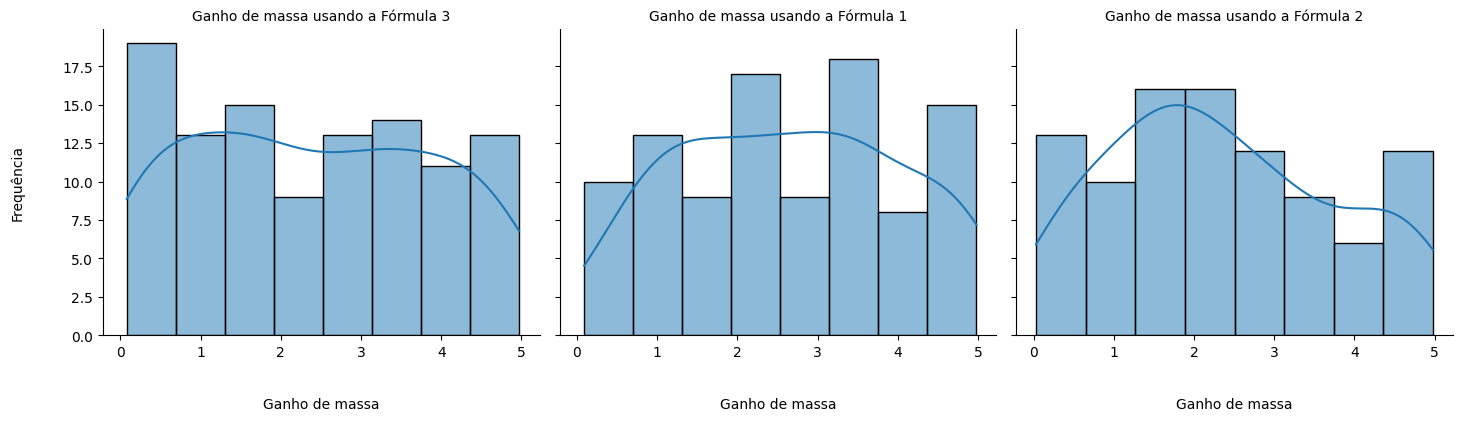

Observando os histogramas, usando a fórmula 3, a maioria dos atletas ganharam de 1 a 2 kg no máximo.

Já usando a fórmula 1, a maioria dos atletas ganharam de 3 a 4 kg.

E, usando a fórmula 2, a maioria dos atletas ganharam de 0 a 2,5 kg.

Ou seja: A fórmula 1 apresenta uma distribuição deslocada para a direita, concentrando a maioria dos atletas no intervalo de 3 a 4 kg de ganho de massa, enquanto a fórmula 2 e 3 concentram seus atletas em intervalos menores e a concentração dos dados está mais a esquerda (0 a 2,5 kg e 1 a 2 kg, respectivamente, no ganho de massa)

# Questão 02

Há diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas?

In [ ]:
from scipy.stats import shapiro
for formula in df_atletas['id_produto'].unique():
  dados = df_atletas[df_atletas['id_produto']==formula]['ganho_massa']

  stat,p = shapiro(dados)

  print(formula)
  print(p)

Fórmula 3
0.00016028433939523925
Fórmula 1
0.0036215293862186925
Fórmula 2
0.0017830518403133568


Considerando um nível de significância de α = 0,05:

H₀: os dados seguem uma distribuição normal.  
H₁: os dados não seguem uma distribuição normal.  

Como todos os p-values são menores que 0,05, rejeitamos H₀ para as três fórmulas. Portanto, há evidências de que os dados de ganho de massa não seguem uma distribuição normal.

Hipótese Nula (H₀):

As distribuições do ganho de massa muscular são iguais entre as três fórmulas. Em outras palavras, não há diferença estatisticamente significativa entre os grupos.

Hipótese Alternativa (H₁):

Pelo menos uma das fórmulas apresenta uma distribuição de ganho de massa diferente das demais.

In [ ]:
from scipy.stats import kruskal

grupo1 = df_atletas[df_atletas['id_produto'] == 'Fórmula 1']['ganho_massa']
grupo2 = df_atletas[df_atletas['id_produto'] == 'Fórmula 2']['ganho_massa']
grupo3 = df_atletas[df_atletas['id_produto'] == 'Fórmula 3']['ganho_massa']

estatistica, p_valor = kruskal(grupo1, grupo2, grupo3)

print(f'Estatística H: {estatistica:.4f}')
print(f'p-value: {p_valor:.4f}')

Estatística H: 2.6473
p-value: 0.2662


Inicialmente foi aplicado o teste de Shapiro-Wilk para verificar a normalidade dos dados de ganho de massa para cada fórmula. Como todas apresentaram p-value inferior a 0,05, concluiu-se que os dados não seguem distribuição normal. Dessa forma, optou-se pelo teste não paramétrico de Kruskal-Wallis para comparar os três grupos.

O teste resultou em uma estatística H = 2,6473 e p-value = 0,2662. Como o p-value é superior ao nível de significância adotado (α = 0,05), não rejeitamos a hipótese nula. Assim, não há evidências estatísticas suficientes para afirmar que as fórmulas apresentam diferenças significativas no ganho de massa muscular.

# Questão 03
Existe correlação entre idade e ganho de massa muscular? Atletas mais jovens ou mais velhos têm resultados diferentes?

In [ ]:
bins = [18, 25, 35, df_atletas['idade'].max()]

labels = ['18-25', '26-35', '36+']

df_atletas['faixa_idade'] = pd.cut(
    df_atletas['idade'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
estatisticas = (
    df_atletas
    .groupby('faixa_idade')['ganho_massa']
    .agg(
        media='mean',
        mediana='median',
        desvio='std',
        quantidade='count'
    )
    .round(2)
)

estatisticas

/tmp/ipykernel_2180/3080641641.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('faixa_idade')['ganho_massa']


,media,mediana,desvio,quantidade
faixa_idade,,,,
18-25,2.56,2.50,1.43,117
26-35,2.43,2.36,1.45,132
36+,2.35,2.13,1.42,51


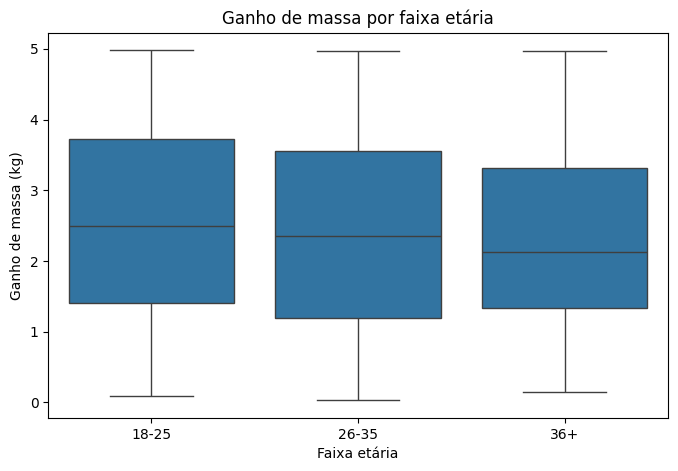

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_atletas,
    x='faixa_idade',
    y='ganho_massa'
)

plt.title('Ganho de massa por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Ganho de massa (kg)')
plt.show()

1. As medianas são muito próximas

18–25 anos possui a maior mediana (~2,5 kg).

26–35 anos é um pouco menor (~2,3 kg).

36+ anos apresenta a menor mediana (~2,1 kg).

Existe uma leve tendência de redução do ganho de massa com o aumento da idade, mas a diferença é pequena.

2. As distribuições são bastante semelhantes
As caixas (intervalo interquartil) possuem alturas parecidas.  
Os "bigodes" também apresentam amplitudes semelhantes.  
Não há uma faixa etária que se destaque claramente com ganhos muito maiores ou muito menores.  

3. Não há outliers aparentes
O gráfico não mostra atletas com ganhos extremamente diferentes do restante.

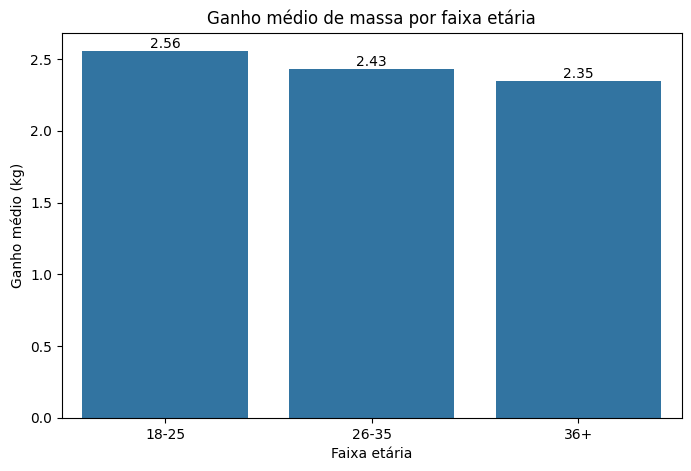

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_atletas,
    x='faixa_idade',
    y='ganho_massa',
    estimator='mean',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Ganho médio de massa por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Ganho médio (kg)')

plt.show()


A análise descritiva por faixa etária mostrou que atletas entre 18 e 25 anos apresentaram ganho médio de massa muscular de 2,56 kg, enquanto atletas de 26 a 35 anos obtiveram média de 2,43 kg e atletas com 36 anos ou mais apresentaram média de 2,35 kg. As medianas acompanharam essa tendência, porém as diferenças observadas foram pequenas. O boxplot evidenciou grande sobreposição entre as distribuições e dispersão semelhante entre as três faixas etárias. Dessa forma, os resultados sugerem que a idade, isoladamente, não exerce influência relevante sobre o ganho de massa muscular após o uso dos suplementos, embora atletas mais jovens tenham apresentado um ganho ligeiramente superior.

In [ ]:
from scipy.stats import spearmanr

coef, p = spearmanr(
    df_atletas['idade'],
    df_atletas['ganho_massa']
)

print('Coeficiente de Spearman: ', coef)
print('p-valor:', p)

Coeficiente de Spearman:  -0.0767850179780001
p-valor: 0.18471970555725858


Hipóteses:

* H₀: Não existe correlação entre idade e ganho de massa.
* H₁: Existe correlação entre idade e ganho de massa.

Como: p = 0.1847 > 0.05

não rejeitamos H₀.


O coeficiente de Spearman varia entre -1 e 1.

-1 → correlação negativa perfeita  
0 → nenhuma correlação  
1 → correlação positiva perfeita  

como ρ = -0.0768, ou seja, próximo de 0

Isso significa que existe uma correlação negativa extremamente fraca, praticamente inexistente.

Para avaliar a relação entre idade e ganho de massa muscular, foi utilizado o coeficiente de correlação de Spearman, uma vez que a variável de interesse não apresentou distribuição normal. O teste resultou em um coeficiente de correlação de ρ = -0,0768 e p-value = 0,1847. Como o p-value é superior ao nível de significância de 5%, não foram encontradas evidências estatísticas suficientes para indicar uma correlação entre a idade e o ganho de massa muscular. Além disso, o coeficiente de Spearman foi muito próximo de zero, indicando uma correlação negativa muito fraca. Esses resultados estão de acordo com a análise descritiva por faixas etárias, que apresentou médias, medianas e dispersões bastante semelhantes entre os grupos. Dessa forma, conclui-se que a idade, isoladamente, não apresenta influência significativa sobre o ganho de massa muscular dos atletas avaliados.

# Questão 04
Atletas que treinam mais frequentemente ganham mais massa muscular independentemente do suplemento?

In [ ]:
bins = [0, 3, 5, 7]

labels = [
    '1-3 treinos',
    '4-5 treinos',
    '6-7 treinos'
]

df_atletas['faixa_treino'] = pd.cut(
    df_atletas['frequencia_treino'],
    bins=bins,
    labels=labels
)

In [ ]:
estatisticas = (
    df_atletas
    .groupby('faixa_treino')['ganho_massa']
    .agg(
        media='mean',
        mediana='median',
        desvio='std',
        quantidade='count'
    )
    .round(2)
)

estatisticas

/tmp/ipykernel_2180/2725903497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('faixa_treino')['ganho_massa']


,media,mediana,desvio,quantidade
faixa_treino,,,,
1-3 treinos,2.37,2.41,1.40,121
4-5 treinos,2.36,2.24,1.43,115
6-7 treinos,2.83,2.70,1.47,64


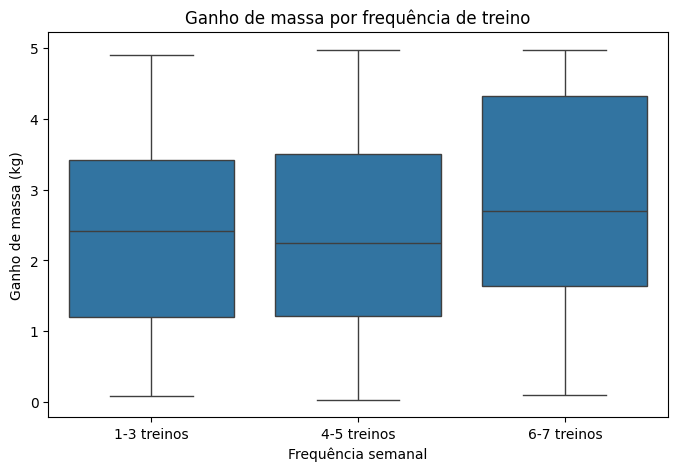

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_atletas,
    x='faixa_treino',
    y='ganho_massa'
)

plt.title('Ganho de massa por frequência de treino')
plt.xlabel('Frequência semanal')
plt.ylabel('Ganho de massa (kg)')

plt.show()

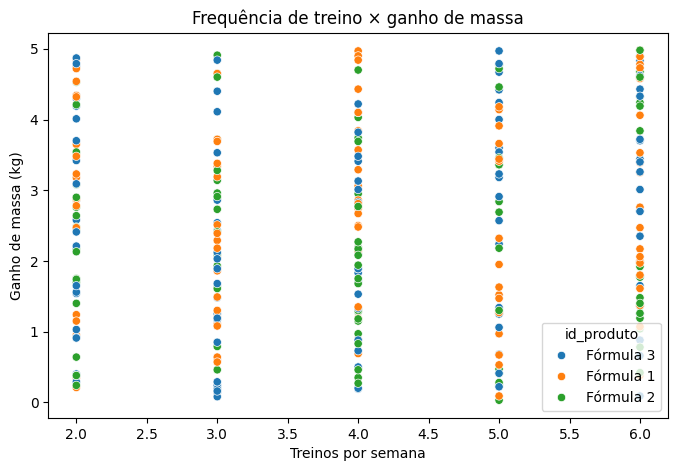

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_atletas,
    x='frequencia_treino',
    y='ganho_massa',
    hue='id_produto'
)

plt.title('Frequência de treino × ganho de massa')
plt.xlabel('Treinos por semana')
plt.ylabel('Ganho de massa (kg)')

plt.show()

Observando o gráfico, nota-se que:

O gráfico de dispersão mostra que atletas com frequência de treino entre 2 e 6 dias por semana apresentam ganhos de massa muscular bastante variados. Em todas as frequências observam-se atletas com ganhos baixos e elevados, sem um padrão crescente ou decrescente evidente. Além disso, as três fórmulas apresentam comportamentos semelhantes ao longo das diferentes frequências de treino. Dessa forma, a análise visual não indica uma relação clara entre a frequência de treino e o ganho de massa muscular.

Ou seja, o gráfico não sugere uma relação evidente entre as variáveis.

In [ ]:
from scipy.stats import spearmanr

coef, p = spearmanr(
    df_atletas['frequencia_treino'],
    df_atletas['ganho_massa']
)

print(f'Coeficiente: {coef:.4f}')
print(f'p-value: {p:.4f}')

Coeficiente: 0.0737
p-value: 0.2033


Hipóteses:

Hipótese Nula (H₀): Não existe correlação entre a frequência de treino e o ganho de massa muscular.

Hipótese Alternativa (H₁): Existe correlação entre a frequência de treino e o ganho de massa muscular.

O coeficiente de Spearman foi:

ρ = 0,0737

Esse valor é muito próximo de zero, indicando uma correlação positiva muito fraca, praticamente inexistente.

Além disso, p = 0,2033

Como: 0,2033 > 0,05

não rejeitamos a hipótese nula.

Para avaliar a relação entre a frequência de treino e o ganho de massa muscular, foi utilizado o coeficiente de correlação de Spearman, uma vez que os dados não apresentaram distribuição normal. O teste resultou em um coeficiente de ρ = 0,0737 e p-value = 0,2033. Como o p-value é superior ao nível de significância de 5%, não foram encontradas evidências estatísticas suficientes para indicar uma correlação entre a frequência de treino e o ganho de massa muscular. Além disso, o coeficiente de Spearman foi muito próximo de zero, indicando uma correlação positiva muito fraca. A análise visual do gráfico de dispersão também não revelou um padrão de aumento do ganho de massa conforme cresce a frequência de treino, mesmo considerando as diferentes fórmulas de suplemento. Dessa forma, os resultados sugerem que atletas que treinam com maior frequência não apresentam, necessariamente, ganhos de massa muscular significativamente maiores.

# Questão 05

Existe alguma correlação entre idade, frequência de treino e a eficácia do suplemento?

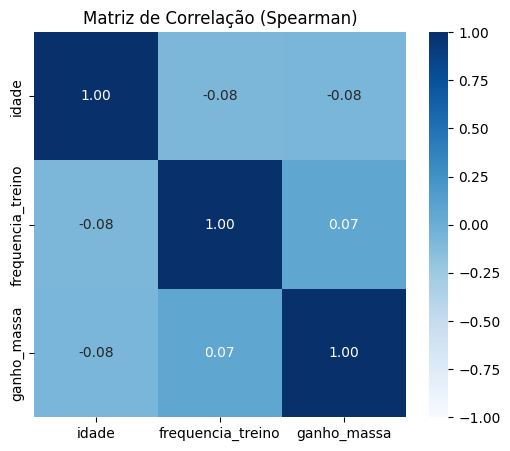

In [ ]:
corr = df_atletas[['idade',
                   'frequencia_treino',
                    'ganho_massa']].corr(method='spearman')

plt.figure(figsize=(6,5))

sns.heatmap(
  corr,
  annot=True,
  cmap='Blues',
  vmin=-1,
  vmax=1,
  fmt='.2f'
)

plt.title('Matriz de Correlação (Spearman)')
plt.show()




A matriz de correlação de Spearman mostra que as correlações entre as variáveis analisadas são muito fracas. A relação entre idade e ganho de massa apresentou coeficiente de ρ = -0,08, indicando uma correlação negativa praticamente inexistente. Da mesma forma, a correlação entre frequência de treino e ganho de massa foi de ρ = 0,07, caracterizando uma correlação positiva muito fraca. Além disso, a relação entre idade e frequência de treino também apresentou coeficiente de ρ = -0,08, sugerindo ausência de associação relevante entre essas variáveis. Assim, de forma geral, não foram observadas correlações significativas entre idade, frequência de treino e ganho de massa muscular.

## Usando ANOVA

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols(
    'ganho_massa ~ C(id_produto) * C(faixa_idade) * frequencia_treino',
    data=df_atletas
).fit()

anova = sm.stats.anova_lm(modelo, typ=2)

print(anova)

                                                    sum_sq     df         F  \
C(id_produto)                                     4.872109    2.0  1.179971   
C(faixa_idade)                                    1.774392    2.0  0.429738   
C(id_produto):C(faixa_idade)                      9.719169    4.0  1.176937   
frequencia_treino                                 3.342549    1.0  1.619057   
C(id_produto):frequencia_treino                   3.117608    2.0  0.755050   
C(faixa_idade):frequencia_treino                  2.420208    2.0  0.586148   
C(id_produto):C(faixa_idade):frequencia_treino    9.531145    4.0  1.154169   
Residual                                        582.190178  282.0       NaN   

                                                  PR(>F)  
C(id_produto)                                   0.308800  
C(faixa_idade)                                  0.651105  
C(id_produto):C(faixa_idade)                    0.321127  
frequencia_treino                               0.20

| Fator                               | p-value | Interpretação     |
| ----------------------------------- | ------: | ----------------- |
| Fórmula                             |  0,3088 | Não significativa |
| Faixa etária                        |  0,6511 | Não significativa |
| Frequência de treino                |  0,2043 | Não significativa |
| Fórmula × Faixa etária              |  0,3211 | Não significativa |
| Fórmula × Frequência                |  0,4709 | Não significativa |
| Faixa etária × Frequência           |  0,5571 | Não significativa |
| Fórmula × Faixa etária × Frequência |  0,3314 | Não significativa |


Para avaliar o efeito conjunto do suplemento, da faixa etária e da frequência de treino sobre o ganho de massa muscular, foi realizada uma análise de variância (ANOVA), conforme orientação da atividade. Inicialmente, a matriz de correlação de Spearman indicou correlações muito fracas entre idade, frequência de treino e ganho de massa muscular, sugerindo ausência de relações monotônicas relevantes entre essas variáveis. Em seguida, o boxplot permitiu visualizar a distribuição do ganho de massa para cada fórmula em diferentes frequências de treino. Embora, visualmente, as Fórmulas 1 e 3 aparentem apresentar ganhos ligeiramente superiores entre atletas que treinam seis vezes por semana, essa diferença é apenas descritiva.

A ANOVA confirmou que nenhum dos fatores avaliados apresentou efeito estatisticamente significativo sobre o ganho de massa muscular (fórmula: p = 0,3088; faixa etária: p = 0,6511; frequência de treino: p = 0,2043). Da mesma forma, as interações entre fórmula e faixa etária (p = 0,3211), fórmula e frequência de treino (p = 0,4709), faixa etária e frequência de treino (p = 0,5571), bem como a interação entre as três variáveis (p = 0,3314), também não foram significativas.

Dessa forma, não foram encontradas evidências estatísticas de que a eficácia do suplemento seja influenciada pela faixa etária, pela frequência de treino ou pela combinação entre essas variáveis.

# Questão 06
Qual fórmula você recomendaria para atletas que treinam mais de 5 vezes por semana? Justifique sua escolha.

Justificativa: A recomendação foi feita com base no cruzamento de métricas de tendência central (mediana) e análise de distribuição (histogramas) para o grupo de alta performance (frequência de treino igual a 6):

Distribuição dos Dados (Histograma): A Fórmula 1 é a única que apresenta sua curva visivelmente deslocada para a direita, concentrando a maior parte dos seus atletas em uma faixa superior de ganho de massa (entre 3 kg e 4 kg), enquanto as demais fórmulas concentram seus atletas mais à esquerda (menores ganhos).

Comportamento no Boxplot (Frequência 6): No subgrupo de atletas que treinam 6 vezes por semana, a Fórmula 1 mantém uma distribuição consistentemente alta e competitiva, superando o declínio acentuado visto na Fórmula 2.